In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/satyamsatyarthi2006/titanic-survival/Titanic-Dataset.xls')

# ── CLEAN ─────────────────────────────────────────────────────────────────────
df['Age'].fillna(df['Age'].median(), inplace=True)
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# ── ENCODE ────────────────────────────────────────────────────────────────────
le = LabelEncoder()
df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

for col in ['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']:
    df[col] = df[col].astype(int)

# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Age_bin']    = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                          labels=[0,1,2,3,4]).astype(int)
df.drop(columns=['SibSp', 'Parch', 'Age'], inplace=True)

print("Shape:", df.shape)
print(df.head())

Shape: (891, 8)
   Survived  Pclass  Sex     Fare  Embarked  FamilySize  IsAlone  Age_bin
0         0       3    1   7.2500         2           2        0        2
1         1       1    0  71.2833         0           2        0        3
2         1       3    0   7.9250         2           1        1        2
3         1       1    0  53.1000         2           2        0        2
4         0       3    1   8.0500         2           1        1        2


In [2]:
X = df.drop('Survived', axis=1)
y = df['Survived']

# KNN is distance-based — scaling is CRITICAL
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# feature selection
X_mm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_mm, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print(feat_scores.to_string(index=False))

drop_cols = feat_scores[feat_scores['P-value'] > 0.05]['Feature'].tolist()
X_scaled  = X_scaled.drop(columns=drop_cols)
print("Final features:", X_scaled.columns.tolist())

   Feature     Score      P-value
       Sex 92.702447 6.077838e-22
    Pclass 27.232933 1.803602e-07
   IsAlone 14.640793 1.300685e-04
      Fare  8.819172 2.980820e-03
  Embarked  5.101262 2.390844e-02
   Age_bin  0.669997 4.130528e-01
FamilySize  0.070909 7.900177e-01
Final features: ['Pclass', 'Sex', 'Fare', 'Embarked', 'IsAlone']


In [3]:
from sklearn.model_selection import train_test_split

X_final = X_scaled
y_final = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
from sklearn.naive_bayes import GaussianNB

# Gaussian NB — used when features are continuous (our case)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# probability estimates for each class
y_pred_proba = gnb.predict_proba(X_test)

comparison = pd.DataFrame({
    'Actual'     : y_test.values,
    'Predicted'  : y_pred,
    'P(Dead)'    : y_pred_proba[:, 0].round(2),
    'P(Survived)': y_pred_proba[:, 1].round(2)
})
print(comparison.head(10))

Train size: (712, 5)
Test size : (179, 5)
   Actual  Predicted  P(Dead)  P(Survived)
0       1          0     0.82         0.18
1       0          0     0.96         0.04
2       0          0     0.98         0.02
3       1          1     0.19         0.81
4       1          1     0.10         0.90
5       1          1     0.04         0.96
6       1          1     0.45         0.55
7       0          0     0.96         0.04
8       1          1     0.45         0.55
9       1          1     0.07         0.93


Accuracy  : 0.7709
Precision : 0.7260
Recall    : 0.7162
F1 Score  : 0.7211


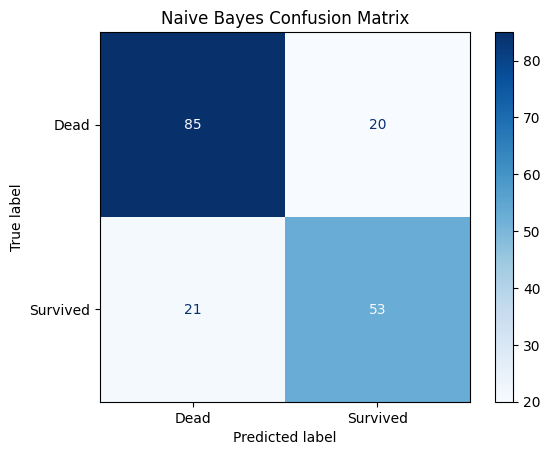


CV Accuracy: 0.7666 ± 0.0398
Each fold  : [0.6927 0.7921 0.8034 0.7584 0.7865]


In [4]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.model_selection import cross_val_score

# metrics
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Dead', 'Survived']).plot(cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# cross validation
scores = cross_val_score(gnb, X_final, y_final, cv=5, scoring='accuracy')
print(f"\nCV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Each fold  : {scores.round(4)}")